In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

In [2]:
dataset=pd.read_csv('Social_Network_Ads.csv')

In [3]:
dataset

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
dataset=pd.get_dummies(dataset,drop_first=True,dtype=int)

In [5]:
dataset

,User ID,Age,EstimatedSalary,Purchased,Gender_Male
0,15624510,19,19000,0,1
1,15810944,35,20000,0,1
2,15668575,26,43000,0,0
3,15603246,27,57000,0,0
4,15804002,19,76000,0,1
...,...,...,...,...,...
395,15691863,46,41000,1,0
396,15706071,51,23000,1,1
397,15654296,50,20000,1,0
398,15755018,36,33000,0,1


In [6]:
dataset.columns

Index(['User ID', 'Age', 'EstimatedSalary', 'Purchased', 'Gender_Male'], dtype='object')

In [7]:
indep=dataset[['Age', 'EstimatedSalary','Gender_Male']]
dep=dataset['Purchased']

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(indep,dep,test_size=1/3,random_state=0)

In [9]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [11]:
from sklearn.svm import SVC
svc = SVC(probability=True)

from sklearn.model_selection import GridSearchCV

param_grid = {'kernel':['linear','rbf','poly','sigmoid'],
             'gamma':['scale','auto'],
             'C':[10,100,1000,2000]} 
grid = GridSearchCV(svc, param_grid, refit = True, verbose = 3,n_jobs=-1,scoring='f1_weighted') 
   
grid.fit(X_train, y_train) 
 



Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [10, 100, 1000, 2000], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             scoring='f1_weighted', verbose=3)

In [12]:
print(grid.best_params_)

{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}


In [13]:

re=grid.cv_results_

grid_predictions = grid.predict(X_test) 

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, grid_predictions)

from sklearn.metrics import classification_report
clf_report = classification_report(y_test, grid_predictions)




In [14]:
print("The confusion Matrix:\n",cm)

The confusion Matrix:
 [[80  5]
 [ 7 42]]


In [15]:
print("The report:\n",clf_report)

The report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93        85
           1       0.89      0.86      0.88        49

    accuracy                           0.91       134
   macro avg       0.91      0.90      0.90       134
weighted avg       0.91      0.91      0.91       134



In [16]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test,grid.predict_proba(X_test)[:,1])


0.9539015606242497

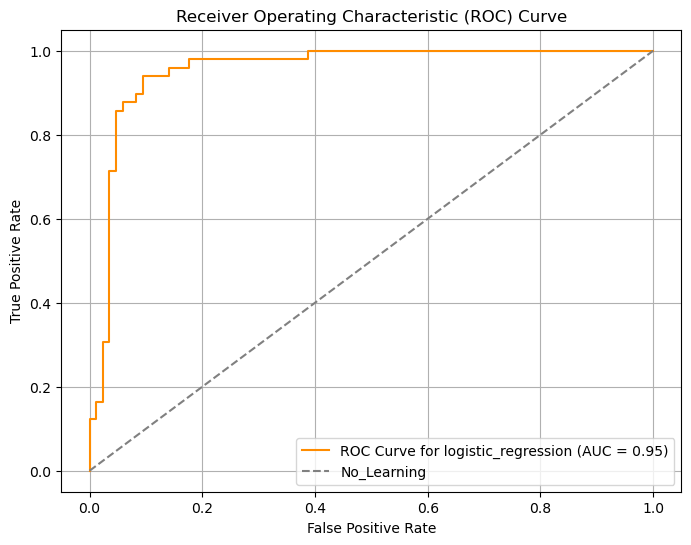

In [17]:
from sklearn.metrics import roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_probs = grid.predict_proba(X_test)[:, 1]

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Plot the ROC curve
plt.figure(figsize=(8, 6))

# Plot ROC curve
plt.plot(fpr, tpr, label=f'ROC Curve for logistic_regression (AUC = {roc_auc_score(y_test, y_probs):.2f})', color='darkorange')

# Plot diagonal line with label
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='No_Learning')

# Add labels and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [18]:
table=pd.DataFrame.from_dict(re)

In [19]:
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.011167,0.001238,0.004051,0.001246,10,scale,linear,"{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}",0.776290,0.790949,0.698235,0.923510,0.901744,0.818146,0.083619,17
1,0.008579,0.001147,0.003849,0.000985,10,scale,rbf,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.867478,0.886792,0.869709,0.944161,0.943041,0.902236,0.034431,3
2,0.010992,0.001221,0.003417,0.000841,10,scale,poly,"{'C': 10, 'gamma': 'scale', 'kernel': 'poly'}",0.799620,0.808392,0.787943,0.924528,0.901744,0.844445,0.056918,9
3,0.007268,0.001293,0.003328,0.000881,10,scale,sigmoid,"{'C': 10, 'gamma': 'scale', 'kernel': 'sigmoid'}",0.762677,0.738916,0.753180,0.778067,0.766556,0.759879,0.013172,25
4,0.012665,0.000980,0.003637,0.000508,10,auto,linear,"{'C': 10, 'gamma': 'auto', 'kernel': 'linear'}",0.776290,0.790949,0.698235,0.923510,0.901744,0.818146,0.083619,17
5,0.009467,0.002103,0.003223,0.000987,10,auto,rbf,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}",0.867478,0.886792,0.869709,0.944161,0.943041,0.902236,0.034431,3
6,0.010481,0.001273,0.002496,0.000770,10,auto,poly,"{'C': 10, 'gamma': 'auto', 'kernel': 'poly'}",0.799620,0.808392,0.787943,0.924528,0.901744,0.844445,0.056918,9
7,0.006522,0.001434,0.002510,0.000452,10,auto,sigmoid,"{'C': 10, 'gamma': 'auto', 'kernel': 'sigmoid'}",0.762677,0.738916,0.655795,0.796284,0.766556,0.744045,0.047743,31
8,0.033625,0.002496,0.002807,0.000982,100,scale,linear,"{'C': 100, 'gamma': 'scale', 'kernel': 'linear'}",0.776290,0.790949,0.698235,0.923510,0.901744,0.818146,0.083619,17
9,0.010727,0.002251,0.003154,0.001144,100,scale,rbf,"{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}",0.867478,0.886792,0.870362,0.944161,0.943041,0.902367,0.034308,1


In [20]:
Social_network_Ads_Prediction=grid.predict([[29,15000,0]])
print("Social_network_Ads_Prediction={}".format(Social_network_Ads_Prediction))

Social_network_Ads_Prediction=[1]
